--- COMPARACIÓN DE MÉTODOS DE OPTIMIZACIÓN (SOLVERS) ---
Solver: liblinear  | Precisión (Accuracy): 0.9500
Solver: newton-cg  | Precisión (Accuracy): 0.9333
Solver: lbfgs      | Precisión (Accuracy): 0.9333
Solver: sag        | Precisión (Accuracy): 0.9333
Solver: saga       | Precisión (Accuracy): 0.9333

--- REPORTE DE CLASIFICACIÓN (Modelo: SAG) ---
               precision    recall  f1-score   support

  0: Nacional       0.88      0.88      0.88        16
1: Extranjero       0.95      0.95      0.95        44

     accuracy                           0.93        60
    macro avg       0.91      0.91      0.91        60
 weighted avg       0.93      0.93      0.93        60


--- PARÁMETROS DEL MODELO ---
Intercepto (Beta 0): [2.55252647]
Pesos de cada variable (Betas): [[ 0.04263368 -0.08908903  2.50748978  1.02639241  3.1055404 ]]


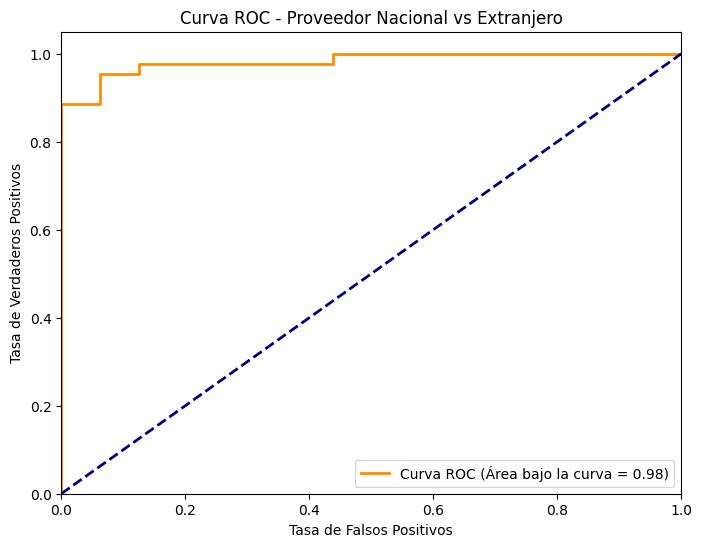


¡Proceso finalizado con éxito! Gráfica 'roc_curve_modelo.png' guardada.


In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, roc_curve, auc

# 1. Configuración de directorio de trabajo
# Ruta exacta proporcionada
ruta_trabajo = r"C:\Users\Yamil\OneDrive\Escritorio\Escritorio\Yamil\EBAC (CIENCIA DE DATOS)\Bloque 4 Aprendizaje de máquina supervisado\MOD 7 Reg Logística"
os.chdir(ruta_trabajo)

# 2. Carga de datos
df = pd.read_csv('drugs.csv')

# 3. Transformación de la Variable a Pronosticar (Nacional vs Extranjero)
# Fármacos A, B, C son Nacionales (0) | Fármacos X, Y son Extranjeros (1)
def transform_drug(drug):
    if drug in ['drugA', 'drugB', 'drugC']:
        return 0 # Nacional
    else:
        return 1 # Extranjero

df['Target'] = df['Drug'].apply(transform_drug)

# Separación de variables predictoras (X) y objetivo (y)
X = df[['Age', 'Sex', 'BP', 'Cholesterol', 'Na_to_K']].copy()
y = df['Target']

# 4. Transformación de variables cualitativas a numéricas usando LabelEncoder
le_sex = preprocessing.LabelEncoder()
X['Sex'] = le_sex.fit_transform(X['Sex']) # F:0, M:1

le_bp = preprocessing.LabelEncoder()
X['BP'] = le_bp.fit_transform(X['BP']) # HIGH:0, LOW:1, NORMAL:2

le_chol = preprocessing.LabelEncoder()
X['Cholesterol'] = le_chol.fit_transform(X['Cholesterol']) # HIGH:0, NORMAL:1

# 5. Separación en datos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Estandarización de los datos (Vital para que el solver 'sag' converja correctamente)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# 6. Evaluación de diversos métodos de optimización (Solvers)
solvers = ['liblinear', 'newton-cg', 'lbfgs', 'sag', 'saga']
resultados_solvers = []

print("--- COMPARACIÓN DE MÉTODOS DE OPTIMIZACIÓN (SOLVERS) ---")
for s in solvers:
    modelo_temp = LogisticRegression(solver=s, max_iter=1000, random_state=42)
    modelo_temp.fit(X_train_scaled, y_train)
    score = modelo_temp.score(X_test_scaled, y_test)
    resultados_solvers.append({'Solver': s, 'Accuracy': score})
    print(f"Solver: {s:10} | Precisión (Accuracy): {score:.4f}")

# 7. Selección del algoritmo óptimo y entrenamiento final
# Elegimos 'sag' por su eficiencia en bases de datos grandes (como pide el contexto del problema)
modelo_final = LogisticRegression(solver='sag', max_iter=1000, random_state=42)
clf = modelo_final.fit(X_train_scaled, y_train)

# Predicciones
y_pred = modelo_final.predict(X_test_scaled)
y_prob = modelo_final.predict_proba(X_test_scaled)[:, 1] # Probabilidades de ser clase 1 (Extranjero)

# 8. Evaluación de Eficacia (Reporte de Clasificación)
print("\n--- REPORTE DE CLASIFICACIÓN (Modelo: SAG) ---")
print(classification_report(y_test, y_pred, target_names=['0: Nacional', '1: Extranjero']))

# Impresión de coeficientes (Justo como lo tienes en tus apuntes de clase)
print("\n--- PARÁMETROS DEL MODELO ---")
print("Intercepto (Beta 0):", clf.intercept_)
print("Pesos de cada variable (Betas):", clf.coef_)

# 9. Curva ROC
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Curva ROC (Área bajo la curva = {roc_auc:.2f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('Tasa de Falsos Positivos')
plt.ylabel('Tasa de Verdaderos Positivos')
plt.title('Curva ROC - Proveedor Nacional vs Extranjero')
plt.legend(loc="lower right")

# Guardar la gráfica en alta calidad para el reporte
plt.savefig('roc_curve_modelo.png', dpi=300, facecolor='white', bbox_inches='tight')
plt.show()

print("\n¡Proceso finalizado con éxito! Gráfica 'roc_curve_modelo.png' guardada.")